# Практическое занятие: Строковые метрики и динамическое программирование
## Кейс: Рассмотрение Расстояния Левенштейна, Дамерау-Левенштейна, алгоритма Вагнера-Фишера и расстояния Жаккара

В данном практическом руководстве рассматриваются алгоритмы динамического программирования для поиска редакционного расстояния между строками, а также теоретико-множественные метрики сходства. Мы разберем:
1. Классическое расстояние Левенштейна (вставка, удаление, замена).
2. Расширение Дамерау-Левенштейна (добавляющее транспозицию соседних символов).
3. Метрику Жаккара (Jaccard Distance) для оценки сходства строк на основе символьных N-грамм без учета их жесткого порядка.


In [1]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Импорт необходимых библиотек для вычислений и визуализации
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import seaborn as sns
from IPython.display import Image, display

# Исходные данные для демонстрации студентам (слова с опечаткой для наглядности транспозиции)
S = "ДЕВОПС"
T = "МОПС"

# Дополнительные строки для демонстрации расстояния Дамерау-Левенштейна (опечатка перестановки)
S_dam = "КТО"
T_dam = "КОТ"

## Расчет матрицы Вагнера-Фишера и обратного пути

В этом разделе мы инициализируем базовую матрицу, заполняем её минимальными стоимостями операций (вставка, удаление, замена), а затем выполняем обратный проход от финальной ячейки к началу, чтобы восстановить цепочку трансформаций.

In [3]:
m, n = len(S), len(T)
D = np.zeros((m + 1, n + 1), dtype=int)

# Заполнение базовых случаев
for i in range(m + 1):
    D[i, 0] = i
for j in range(n + 1):
    D[0, j] = j

# Автоматический словарь для хранения формул шагов
formulas = {}

# Пошаговое вычисление матрицы Левенштейна
for i in range(1, m + 1):
    for j in range(1, n + 1):
        char_s = S[i - 1]
        char_t = T[j - 1]
        
        val_del = D[i - 1, j] + 1
        val_ins = D[i, j - 1] + 1
        val_sub = D[i - 1, j - 1] + (0 if char_s == char_t else 1)
        
        if char_s == char_t:
            D[i, j] = D[i - 1, j - 1]
        else:
            D[i, j] = min(val_del, val_ins, val_sub)
            
        # Автоматически генерируем пояснение для первых 4 ячеек каждой строки
        if j <= 4:
            sub_action = f"Совпадение '{char_s}'" if char_s == char_t else f"Замена '{char_s}'->'{char_t}'"
            formulas[(i, j)] = (
                f"D[{i}][{j}] = min(\n"
                f"  D[{i-1}][{j}] + 1 [Удаление] = {val_del},\n"
                f"  D[{i}][{j-1}] + 1 [Вставка] = {val_ins},\n"
                f"  D[{i-1}][{j-1}] + c [{(sub_action)}] = {val_sub}\n"
                f") = {D[i, j]}"
            )

# Расчет обратного пути (Backtrace)
path = []
curr_i, curr_j = m, n
path.append((curr_i, curr_j))

while curr_i > 0 or curr_j > 0:
    if curr_i > 0 and curr_j > 0 and S[curr_i - 1] == T[curr_j - 1]:
        curr_i, curr_j = curr_i - 1, curr_j - 1
    else:
        candidates = []
        if curr_i > 0 and curr_j > 0: 
            candidates.append((D[curr_i - 1, curr_j - 1], (curr_i - 1, curr_j - 1)))
        if curr_i > 0:           
            candidates.append((D[curr_i - 1, curr_j], (curr_i - 1, curr_j)))
        if curr_j > 0:           
            candidates.append((D[curr_i, curr_j - 1], (curr_i, curr_j - 1)))
        
        _, best_cell = min(candidates, key=lambda x: x[0])
        curr_i, curr_j = best_cell
    path.append((curr_i, curr_j))

path.reverse()


## Визуализация и анимация алгоритма Левенштейна

Для повышения наглядности мы автоматически генерируем текстовые формулы-пояснения для первых четырёх ячеек первой рабочей строки.

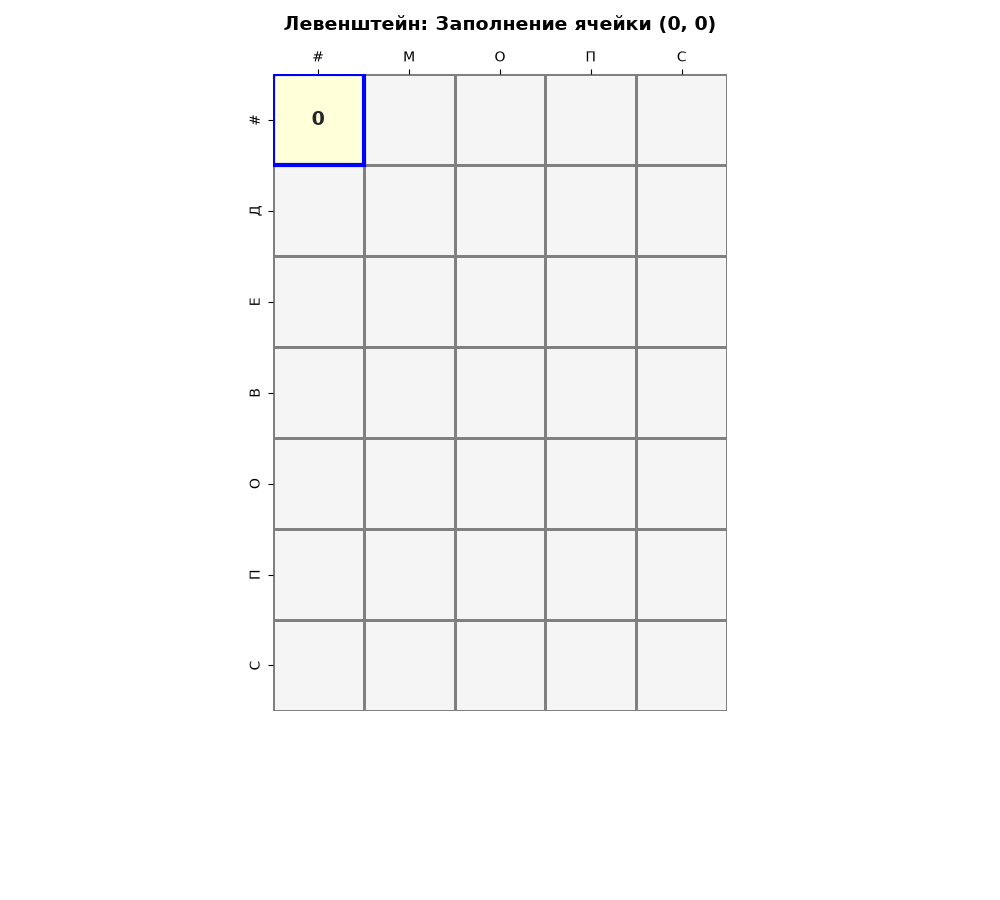

In [4]:
base_frames = []
for i in range(m + 1):
    for j in range(n + 1):
        base_frames.append(('calc', i, j, ""))

for _ in range(5):
    base_frames.append(('calc', m, n, ""))

for idx, (pi, pj) in enumerate(path):
    base_frames.append(('path', pi, pj, path[:idx+1]))

for _ in range(10):
    base_frames.append(('path', path[-1][0], path[-1][1], path))

extended_frames = []
for f in base_frames:
    extended_frames.append(f)
    if f[0] == 'calc' and (f[1], f[2]) in formulas:
        for _ in range(6):  # Динамическая задержка на формулах
            extended_frames.append(f)

x_labels = ['#'] + list(T)
y_labels = ['#'] + list(S)

fig = plt.figure(figsize=(10, 9))
gs = fig.add_gridspec(2, 1, height_ratios=[4, 1])
ax_map = fig.add_subplot(gs[0])
ax_text = fig.add_subplot(gs[1])

def update(frame_idx):
    ax_map.clear()
    ax_text.clear()
    ax_text.axis('off')
    
    frame = extended_frames[frame_idx]
    frame_type, curr_i, curr_j, current_path = frame
    display_matrix = np.full((m + 1, n + 1), np.nan)
    
    if frame_type == 'calc':
        for i in range(m + 1):
            for j in range(n + 1):
                if (i < curr_i) or (i == curr_i and j <= curr_j):
                    display_matrix[i, j] = D[i, j]
        title = f"Левенштейн: Заполнение ячейки ({curr_i}, {curr_j})"
        
        if (curr_i, curr_j) in formulas:
            ax_text.text(0.5, 0.5, formulas[(curr_i, curr_j)], 
                         fontsize=10, family='monospace', weight='bold',
                         ha='center', va='center', color='darkred',
                         bbox=dict(facecolor='lightyellow', edgecolor='orange', boxstyle='round,pad=0.5'))
            rect_neighbors = plt.Rectangle((curr_j - 1, curr_i - 1), 2, 2, fill=False, edgecolor='darkred', linewidth=2, linestyle='--')
            ax_map.add_patch(rect_neighbors)
    else:
        display_matrix = D.astype(float)
        title = "Восстановление пути (Backtrace)"
        ax_text.text(0.5, 0.5, f"Текущая позиция пути: ({curr_i}, {curr_j})\nИтоговое расстояние Левенштейна = {D[m, n]}", 
                     fontsize=12, weight='bold', ha='center', va='center', color='blue')

    sns.heatmap(display_matrix, annot=True, fmt=".0f", cmap="YlGnBu", cbar=False,
                xticklabels=x_labels, yticklabels=y_labels, square=True, ax=ax_map,
                annot_kws={"size": 14, "weight": "bold"}, linewidths=1, linecolor='gray',
                mask=np.isnan(display_matrix))
    
    ax_map.set_facecolor('#f5f5f5')
    
    if frame_type == 'path':
        if len(current_path) > 1:
            px, py = zip(*[(pj + 0.5, pi + 0.5) for pi, pj in current_path])
            ax_map.plot(px, py, color='red', linewidth=4, marker='o', markersize=8, zorder=5)
        rect = plt.Rectangle((curr_j, curr_i), 1, 1, fill=False, edgecolor='red', linewidth=4, zorder=6)
        ax_map.add_patch(rect)
    elif frame_type == 'calc':
        rect = plt.Rectangle((curr_j, curr_i), 1, 1, fill=False, edgecolor='blue', linewidth=3, zorder=6)
        ax_map.add_patch(rect)

    ax_map.set_title(title, fontsize=14, pad=15, weight='bold')
    ax_map.xaxis.tick_top()
    ax_map.xaxis.set_label_position('top')
    plt.tight_layout()

os.makedirs("generated", exist_ok=True)
ani = animation.FuncAnimation(fig, update, frames=len(extended_frames), interval=200)
ani.save('generated/levenshtein_animation.gif', writer='pillow', fps=5)
plt.close()

# Вывод анимации
display(Image(filename='generated/levenshtein_animation.gif'))


## Алгоритм Дамерау-Левенштейна (Ограниченное расстояние)

Расстояние Дамерау-Левенштейна учитывает перестановку двух соседних символов (транспозицию) как единую операцию со стоимостью 1. Это критически важно для исправления человеческих опечаток (например, "КТО" -> "КОТ"). 

Формула dynamic программирования расширяется четвертым условием:
Если 

$S[i-1] == T[j-2]$ и $S[i-2] == T[j-1]$, то:
$D[i, j] = min(..., D[i-2, j-2] + 1)$

In [5]:
m_dam, n_dam = len(S_dam), len(T_dam)
D_dam = np.zeros((m_dam + 1, n_dam + 1), dtype=int)

# Инициализация базовых векторов
for i in range(m_dam + 1):
    D_dam[i, 0] = i
for j in range(n_dam + 1):
    D_dam[0, j] = j

formulas_dam = {}

# Вычисление матрицы с учетом транспозиции
for i in range(1, m_dam + 1):
    for j in range(1, n_dam + 1):
        char_s = S_dam[i - 1]
        char_t = T_dam[j - 1]
        
        val_del = D_dam[i - 1, j] + 1
        val_ins = D_dam[i, j - 1] + 1
        val_sub = D_dam[i - 1, j - 1] + (0 if char_s == char_t else 1)
        
        # Базовый выбор из трех стандартных операций
        if char_s == char_t:
            D_dam[i, j] = D_dam[i - 1, j - 1]
        else:
            D_dam[i, j] = min(val_del, val_ins, val_sub)
            
        # Проверка условия транспозиции (Дамерау)
        transposition_triggered = False
        val_trans = None
        if i > 1 and j > 1 and S_dam[i - 1] == T_dam[j - 2] and S_dam[i - 2] == T_dam[j - 1]:
            val_trans = D_dam[i - 2, j - 2] + 1
            if val_trans < D_dam[i, j]:
                D_dam[i, j] = val_trans
                transposition_triggered = True
                
        # Автоматическая генерация формулы-пояснения для Дамерау
        sub_action = f"Совпадение '{char_s}'" if char_s == char_t else f"Замена '{char_s}'->'{char_t}'"
        trans_str = f",\n  D[{i-2}][{j-2}] + 1 [Транспозиция] = {val_trans}" if val_trans is not None else ""
        if transposition_triggered:
            sub_action += " (Перекрыто транспозицией)"
            
        formulas_dam[(i, j)] = (
            f"D_dam[{i}][{j}] = min(\n"
            f"  D[{i-1}][{j}] + 1 [Удаление] = {val_del},\n"
            f"  D[{i}][{j-1}] + 1 [Вставка] = {val_ins},\n"
            f"  D[{i-1}][{j-1}] + c [{sub_action}] = {val_sub}{trans_str}\n"
            f") = {D_dam[i, j]}"
        )

# Восстановление пути для Дамерау (Backtrace)
path_dam = []
curr_i, curr_j = m_dam, n_dam
path_dam.append((curr_i, curr_j))

while curr_i > 0 or curr_j > 0:
    candidates = []
    # Если возможно совпадение или замена
    if curr_i > 0 and curr_j > 0:
        if S_dam[curr_i - 1] == T_dam[curr_j - 1]:
            if D_dam[curr_i, curr_j] == D_dam[curr_i - 1, curr_j - 1]:
                curr_i, curr_j = curr_i - 1, curr_j - 1
                path_dam.append((curr_i, curr_j))
                continue
        candidates.append((D_dam[curr_i - 1, curr_j - 1], (curr_i - 1, curr_j - 1)))
        
    # Проверка шага транспозиции назад
    if curr_i > 1 and curr_j > 1 and S_dam[curr_i - 1] == T_dam[curr_j - 2] and S_dam[curr_i - 2] == T_dam[curr_j - 1]:
        if D_dam[curr_i, curr_j] == D_dam[curr_i - 2, curr_j - 2] + 1:
            curr_i, curr_j = curr_i - 2, curr_j - 2
            path_dam.append((curr_i, curr_j))
            continue
            
    if curr_i > 0: candidates.append((D_dam[curr_i - 1, curr_j], (curr_i - 1, curr_j)))
    if curr_j > 0: candidates.append((D_dam[curr_i, curr_j - 1], (curr_i, curr_j - 1)))
    
    _, best_cell = min(candidates, key=lambda x: x[0])
    curr_i, curr_j = best_cell
    path_dam.append((curr_i, curr_j))

path_dam.reverse()


## Визуализация и анимация алгоритма Дамерау-Левенштейна

Создаем отдельную анимацию для демонстрации превосходства алгоритма Дамерау-Левенштейна при обработке перестановок букв.


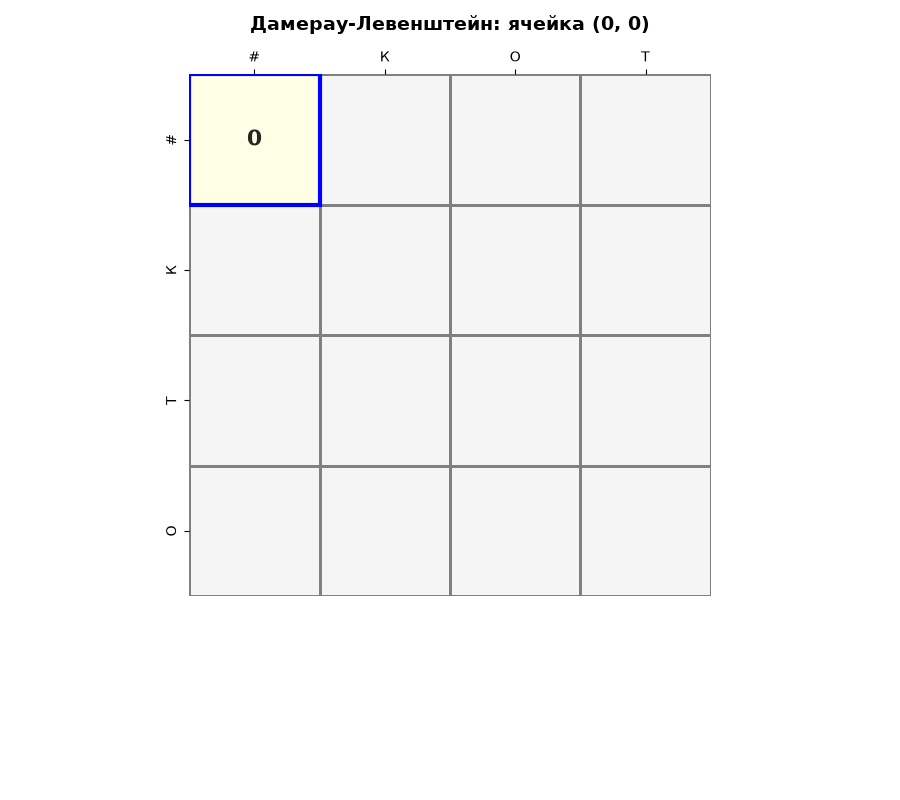

In [6]:
base_frames_dam = []
for i in range(m_dam + 1):
    for j in range(n_dam + 1):
        base_frames_dam.append(('calc', i, j, ""))

for _ in range(5):
    base_frames_dam.append(('calc', m_dam, n_dam, ""))

for idx, (pi, pj) in enumerate(path_dam):
    base_frames_dam.append(('path', pi, pj, path_dam[:idx+1]))

for _ in range(10):
    base_frames_dam.append(('path', path_dam[-1][0], path_dam[-1][1], path_dam))

extended_frames_dam = []
for f in base_frames_dam:
    extended_frames_dam.append(f)
    if f[0] == 'calc' and (f[1], f[2]) in formulas_dam:
        for _ in range(8):  # Увеличенная задержка для чтения формул Дамерау
            extended_frames_dam.append(f)

x_labels_dam = ['#'] + list(T_dam)
y_labels_dam = ['#'] + list(S_dam)

fig_dam = plt.figure(figsize=(9, 8))
gs_dam = fig_dam.add_gridspec(2, 1, height_ratios=[3, 1])
ax_map_dam = fig_dam.add_subplot(gs_dam[0])
ax_text_dam = fig_dam.add_subplot(gs_dam[1])

def update_dam(frame_idx):
    ax_map_dam.clear()
    ax_text_dam.clear()
    ax_text_dam.axis('off')
    
    frame = extended_frames_dam[frame_idx]
    frame_type, curr_i, curr_j, current_path = frame
    display_matrix = np.full((m_dam + 1, n_dam + 1), np.nan)
    
    if frame_type == 'calc':
        for i in range(m_dam + 1):
            for j in range(n_dam + 1):
                if (i < curr_i) or (i == curr_i and j <= curr_j):
                    display_matrix[i, j] = D_dam[i, j]
        title = f"Дамерау-Левенштейн: ячейка ({curr_i}, {curr_j})"
        
        if (curr_i, curr_j) in formulas_dam:
            ax_text_dam.text(0.5, 0.5, formulas_dam[(curr_i, curr_j)], 
                             fontsize=10, family='monospace', weight='bold',
                             ha='center', va='center', color='darkgreen',
                             bbox=dict(facecolor='lightcyan', edgecolor='teal', boxstyle='round,pad=0.5'))
            
            # Дополнительное визуальное выделение блока 2х2 для транспозиции
            if curr_i > 1 and curr_j > 1:
                rect_trans = plt.Rectangle((curr_j - 2, curr_i - 2), 2, 2, fill=False, edgecolor='teal', linewidth=2, linestyle=':')
                ax_map_dam.add_patch(rect_trans)
    else:
        display_matrix = D_dam.astype(float)
        title = "Восстановление пути Дамерау (Backtrace)"
        ax_text_dam.text(0.5, 0.5, f"Текущая позиция обратного пути: ({curr_i}, {curr_j})\nИтоговое расстояние Дамерау-Левенштейна = {D_dam[m_dam, n_dam]}", 
                         fontsize=12, weight='bold', ha='center', va='center', color='teal')

    sns.heatmap(display_matrix, annot=True, fmt=".0f", cmap="YlOrBr", cbar=False,
                xticklabels=x_labels_dam, yticklabels=y_labels_dam, square=True, ax=ax_map_dam,
                annot_kws={"size": 16, "weight": "bold"}, linewidths=1, linecolor='gray',
                mask=np.isnan(display_matrix))
    
    ax_map_dam.set_facecolor('#f5f5f5')
    
    if frame_type == 'path':
        if len(current_path) > 1:
            px, py = zip(*[(pj + 0.5, pi + 0.5) for pi, pj in current_path])
            ax_map_dam.plot(px, py, color='darkgreen', linewidth=4, marker='o', markersize=8, zorder=5)
        rect = plt.Rectangle((curr_j, curr_i), 1, 1, fill=False, edgecolor='darkgreen', linewidth=4, zorder=6)
        ax_map_dam.add_patch(rect)
    elif frame_type == 'calc':
        rect = plt.Rectangle((curr_j, curr_i), 1, 1, fill=False, edgecolor='blue', linewidth=3, zorder=6)
        ax_map_dam.add_patch(rect)

    ax_map_dam.set_title(title, fontsize=14, pad=15, weight='bold')
    ax_map_dam.xaxis.tick_top()
    ax_map_dam.xaxis.set_label_position('top')
    plt.tight_layout()

ani_dam = animation.FuncAnimation(fig_dam, update_dam, frames=len(extended_frames_dam), interval=220)
ani_dam.save('generated/damerau_levenshtein_animation.gif', writer='pillow', fps=5)
plt.close()

# Вывод анимации Дамерау-Левенштейна
display(Image(filename='generated/damerau_levenshtein_animation.gif'))

## Коэффициент сходства и расстояние Жаккара (Jaccard Distance)

В отличие от расстояния Левенштейна, которое чувствительно к порядку символов, **Метрика Жаккара** оценивает степень сходства множеств. Для применения к строкам, текст разбивается на множество элементов (уникальных символов или символьных $N$-грамм).


In [7]:
def jaccard_distance(str1, str2, n=1):
    """
    Вычисляет символьное сходство и расстояние Жаккара на основе N-грамм.
    n=1 означает посимвольное сравнение.
    """
    # Функция для генерации N-грамм из строки
    def get_ngrams(text, n_size):
        if len(text) < n_size:
            return set([text])
        return set(text[i:i+n_size] for i in range(len(text) - n_size + 1))
    
    # Выделяем множества элементов
    set1 = get_ngrams(str1, n)
    set2 = get_ngrams(str2, n)
    
    # Находим пересечение и объединение множеств
    intersection = set1.intersection(set2)
    union = set1.union(set2)
    
    # Расчет метрик
    jaccard_index = len(intersection) / len(union) if len(union) > 0 else 0.0
    jaccard_dist = 1.0 - jaccard_index
    
    return jaccard_index, jaccard_dist, set1, set2, intersection, union

# Проверим на исходных строках занятия (S = "ДЕВОПС", T = "МОПС")
j_index, j_dist, s1, s2, inter, uni = jaccard_distance(S, T, n=1)

print(f"=== РАСЧЕТ РАССТОЯНИЯ ЖАККАРА (Посимвольно, N=1) ===")
print(f"Строка 1 (S): '{S}' -> Множество: {s1}")
print(f"Строка 2 (T): '{T}' -> Множество: {s2}")
print(f"Пересечение (S ∩ T): {inter} (размер: {len(inter)})")
print(f"Объединение (S ∪ T): {uni} (размер: {len(uni)})")
print(f"Коэффициент сходства Жаккара (Jaccard Index): {j_index:.4f}")
print(f"Расстояние Жаккара (Jaccard Distance): {j_dist:.4f}\n")

# Проверим на парах с транспозицией (S_dam = "КТО", T_dam = "КОТ")
j_index_dam, j_dist_dam, _, _, _, _ = jaccard_distance(S_dam, T_dam, n=1)
print(f"=== РАСЧЕТ ДЛЯ ПАРАДОКСА ТРАНСПОЗИЦИИ ('{S_dam}' и '{T_dam}') ===")
print(f"Расстояние Левенштейна: {D_dam[m_dam, n_dam]} (с учетом транспозиции)")
print(f"Посимвольное расстояние Жаккара (N=1): {j_dist_dam:.4f} (метрика равна 0, так как множества букв идентичны!)")

# Демонстрация улучшения чувствительности с помощью биграмм (N=2)
j_index_b, j_dist_b, s1_b, s2_b, inter_b, uni_b = jaccard_distance(S_dam, T_dam, n=2)
print(f"\nПрименяем биграммы (N=2) для учета порядка букв:")
print(f"Биграммы '{S_dam}': {s1_b}")
print(f"Биграммы '{T_dam}': {s2_b}")
print(f"Расстояние Жаккара на биграммах (N=2): {j_dist_b:.4f} (теперь метрика уловила разницу в порядке символов!)")


=== РАСЧЕТ РАССТОЯНИЯ ЖАККАРА (Посимвольно, N=1) ===
Строка 1 (S): 'ДЕВОПС' -> Множество: {'П', 'Д', 'В', 'Е', 'С', 'О'}
Строка 2 (T): 'МОПС' -> Множество: {'С', 'М', 'О', 'П'}
Пересечение (S ∩ T): {'С', 'О', 'П'} (размер: 3)
Объединение (S ∪ T): {'П', 'Д', 'В', 'Е', 'С', 'М', 'О'} (размер: 7)
Коэффициент сходства Жаккара (Jaccard Index): 0.4286
Расстояние Жаккара (Jaccard Distance): 0.5714

=== РАСЧЕТ ДЛЯ ПАРАДОКСА ТРАНСПОЗИЦИИ ('КТО' и 'КОТ') ===
Расстояние Левенштейна: 1 (с учетом транспозиции)
Посимвольное расстояние Жаккара (N=1): 0.0000 (метрика равна 0, так как множества букв идентичны!)

Применяем биграммы (N=2) для учета порядка букв:
Биграммы 'КТО': {'ТО', 'КТ'}
Биграммы 'КОТ': {'ОТ', 'КО'}
Расстояние Жаккара на биграммах (N=2): 1.0000 (теперь метрика уловила разницу в порядке символов!)
